In [2]:
import numpy as np

A = np.array([
    [1, 5, 4],
    [3, 1, 1],
    [6 ,4, 2]
])

B = np.array([
    [4, 3, 1],
    [5, 8, 3],
    [1, 2, 1]
])

C = A * B
print("Matrix A:\n", A )
print("Matrix B:\n", B )
print("Element-wise Product C:\n", C)

D = np.sum(C, axis=1)
print("Sum of each row in C:\n", D)


Matrix A:
 [[1 5 4]
 [3 1 1]
 [6 4 2]]
Matrix B:
 [[4 3 1]
 [5 8 3]
 [1 2 1]]
Element-wise Product C:
 [[ 4 15  4]
 [15  8  3]
 [ 6  8  2]]
Sum of each row in C:
 [23 26 16]



# Batch Image Similarity Using Dot Product

## 1. Import Required Libraries

```python
from matplotlib import pyplot as plt
import numpy as np
```

* **NumPy** → used for numerical operations and array manipulation.
* **Matplotlib** → used to display images.

---

# 2. Create Two Image Batches

```python
batch_A = np.random.randint(0, 255, (4,5,5))
print (f"Batch A image array:\n{batch_A}")

batch_B = np.random.randint(0, 255, (4,5,5))
print (f"Batch B image array:\n{batch_B}")
```

### Explanation

* `(4,5,5)` means:

| Dimension | Meaning          |
| --------- | ---------------- |
| 4         | Number of images |
| 5         | Image height     |
| 5         | Image width      |

So each batch contains **4 grayscale images of size 5×5**.

Each pixel value ranges from **0 to 254** representing grayscale intensity.

---

# 3. Flatten the Images

```python
batch_A_flattened = batch_A.reshape(4, -1)
print (f"Batch A flattened array:\n{batch_A_flattened}")

batch_B_flattened = batch_B.reshape(4, -1)
print (f"Batch B flattened array:\n{batch_B_flattened}")
```

### Explanation

Images must be converted to **vectors** before calculating similarity.

Original shape:

```
(4, 5, 5)
```

Flattened shape:

```
(4, 25)
```

Because:

$$
5 \times 5 = 25
$$

Each image becomes a **25-element vector**.

Example:

Original Image

```
[[1 2 3]
 [4 5 6]
 [7 8 9]]
```

Flattened

```
[1 2 3 4 5 6 7 8 9]
```

---

# 4. Compute Similarity Scores

```python
similarity_scores = np.sum(batch_A_flattened * batch_B_flattened, axis=1)
print (f"Similarity scores between corresponding images in Batch A and Batch B:\n{similarity_scores}")
```

### Explanation

This calculates the **dot product similarity** between corresponding images.

Steps performed:

01. Multiply vectors element-wise

```
A * B
```

02. Sum all values

$$
Similarity = \sum (A_i \times B_i)
$$

`axis=1` means the calculation is done **for each image pair**.

Result:

```
[score1, score2, score3, score4]
```

Each score represents similarity between:

| Pair   | Compared Images |
| ------ | --------------- |
| score1 | A₁ vs B₁        |
| score2 | A₂ vs B₂        |
| score3 | A₃ vs B₃        |
| score4 | A₄ vs B₄        |

Higher score → images are **more similar**.

---

# 5. Visualizing the Images

```python
for i in range(4):
    
    plt.subplot(1,2,1)
    plt.imshow(batch_A[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Batch A - Image {i+1}')
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(batch_B[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Batch B - Image {i+1}')
    plt.axis('off')
    
    plt.show()
    print(f"Similarity score for Image {i+1}: {similarity_scores[i]}")
```

### Explanation

For each image pair:

1. Display **Image from Batch A**
2. Display **Corresponding Image from Batch B**
3. Print their **similarity score**

The layout:

```
[ Batch A Image ]   [ Batch B Image ]
```

Then the similarity score is printed.

Example output:

```
Similarity score for Image 1: 412345
Similarity score for Image 2: 398212
Similarity score for Image 3: 420199
Similarity score for Image 4: 401555
```

---

# Final Workflow

```
Create Image Batches
        ↓
Flatten Images
        ↓
Compute Dot Product Similarity
        ↓
Visualize Image Pairs
        ↓
Print Similarity Scores
```

---

**Important Concept**

This code demonstrates **Vector Similarity in Image Processing**.

Each image is treated as a **vector in 25-dimensional space**.

Similarity is measured using the **dot product**:

$$
A \cdot B = |A||B|\cos(\theta)
$$

Where:

* (θ) = angle between vectors
* Smaller angle → more similar images

---

Batch A image array:
[[[ 59 159 202 222  33]
  [140  93  60  32 147]
  [140 240 128 186 146]
  [ 46 231 192 219 172]
  [202  21 111 123  11]]

 [[ 42   8  44 239 157]
  [117   9 209  13 247]
  [ 26  34 145 216 241]
  [226 188 140  58  87]
  [114 156 219 120  54]]

 [[138 217 101 130 202]
  [ 33 247 176 115 197]
  [188 241 228 136  61]
  [ 66  68 155 222  50]
  [ 51  40  34  85  53]]

 [[107 208 148 181 225]
  [184  73  79  86 193]
  [159 117  47 130 224]
  [162 140 195 181  67]
  [154  95 159 205 208]]]
Batch B image array:
[[[ 78 191 252  32 177]
  [124 100 236  69  87]
  [148 155 154   8 115]
  [ 46  78  14 211  41]
  [  1  65  61 202 177]]

 [[125  83 246 219 133]
  [121 194 186 215  51]
  [ 68 244 246 146 206]
  [118 251  55  61 112]
  [176 206 186 207 113]]

 [[ 58 159  55  47 114]
  [228 198 126 232 193]
  [ 87 103 139 180  44]
  [ 98 185 230  81 115]
  [ 64 193 245 183 238]]

 [[ 41 247 205  34 242]
  [160 254  23  64 234]
  [168 219 153  49 189]
  [122 199 192  98 126]
  [198 1

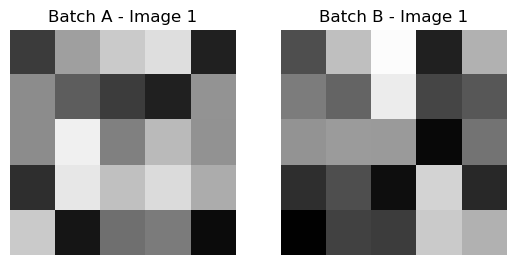

Similarity score for Image 1: 361761


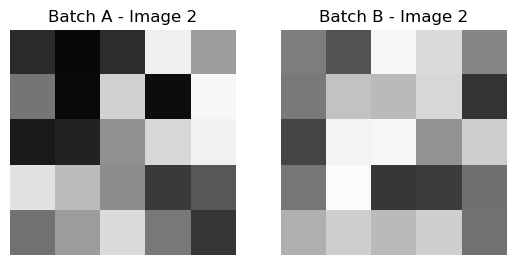

Similarity score for Image 2: 505759


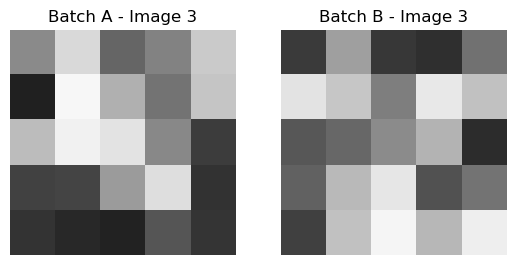

Similarity score for Image 3: 446455


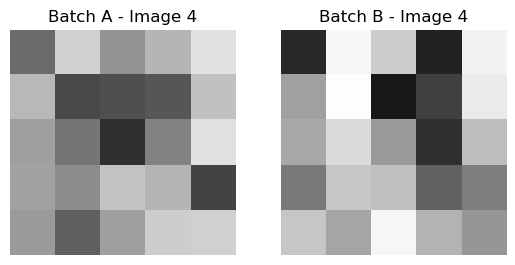

Similarity score for Image 4: 620029


In [21]:
from matplotlib import pyplot as plt
import numpy as np

batch_A = np.random.randint(0, 255, (4,5,5))
print (f"Batch A image array:\n{batch_A}")

batch_B = np.random.randint(0, 255, (4,5,5))
print (f"Batch B image array:\n{batch_B}")

batch_A_flattened = batch_A.reshape(4, -1)
print (f"Batch A flattened array:\n{batch_A_flattened}")

batch_B_flattened = batch_B.reshape(4, -1)
print (f"Batch B flattened array:\n{batch_B_flattened}")


similarity_scores = np.sum(batch_A_flattened * batch_B_flattened, axis=1)
print (f"Similarity scores between corresponding images in Batch A and Batch B:\n{similarity_scores}")


for i in range(4):
    
    plt.subplot(1,2,1)
    plt.imshow(batch_A[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Batch A - Image {i+1}')
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(batch_B[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Batch B - Image {i+1}')
    plt.axis('off')
    
    plt.show()
    print(f"Similarity score for Image {i+1}: {similarity_scores[i]}")